# Policy Gradient Methods: REINFORCE and Actor-Critic

## Lab Objectives

In this lab, you will:
1. **Implement REINFORCE algorithm** - Monte Carlo policy gradient
2. **Implement Actor-Critic algorithm** - Hybrid policy gradient with value function
3. **Compare three methods** on **two environments**:
   - Your best **Double-DQN** from previous lab
   - **REINFORCE** (this lab)
   - **Actor-Critic** (this lab)
4. **Analyze results** on:
   - **CartPole-v1** (familiar environment)
   - **Acrobot-v1** (new challenging environment)

## What You'll Learn

- Direct policy optimization vs value-based methods
- The high variance problem in policy gradients
- How Actor-Critic reduces variance
- Comparative analysis of different RL algorithms

## Theoretical Background

### 1. Policy Gradient Theorem

**Objective**: Maximize expected cumulative reward

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[G_t] = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \gamma^t r_t\right]$$

where $\tau = (s_0, a_0, r_0, s_1, \ldots)$ is a trajectory sampled from policy $\pi_\theta$.

**The Policy Gradient Theorem** provides a way to optimize policies directly:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

**Key Insight**: We can estimate the gradient using samples!

1. Collect trajectories by running $\pi_\theta$ in environment
2. Compute returns $G_t$ for each timestep
3. Compute gradient: $\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Update: $\theta \leftarrow \theta + \alpha \nabla_\theta J(\theta)$

### 2. REINFORCE Algorithm

**REINFORCE** implements the policy gradient theorem directly:

1. Generate episode: $s_0, a_0, r_0, \ldots, s_T, a_T, r_T$
2. For each timestep $t$:
   - Compute return: $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$
3. Compute loss: $L = -\sum_t \log \pi_\theta(a_t|s_t) \cdot G_t$
4. Backpropagate: $\theta \leftarrow \theta + \alpha \nabla_\theta L$

**Problem**: High variance! $G_t$ varies a lot between trajectories.

### 3. Actor-Critic: Reducing Variance

**The High Variance Problem**: REINFORCE uses Monte Carlo returns $G_t$:
- Must wait until episode ends
- $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
- High variance: small changes in actions cause big changes in $G_t$

**Solution: Use a Value Function (Critic)**

Instead of full return $G_t$, use TD learning:
- Critic estimates $V(s; w)$
- TD error: $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$
- Use $\delta_t$ as \"advantage estimate\" for actor update

**Actor-Critic Architecture**:

1. **Actor**: Policy network $\pi(a|s; \theta)$ - selects actions
2. **Critic**: Value network $V(s; w)$ - estimates state value

**Update Rules**:

Critic: $w \leftarrow w - \alpha_w \cdot \nabla_w [\delta_t^2]$ where $\delta_t = r_t + \gamma V(s_{t+1}; w) - V(s_t; w)$

Actor: $\theta \leftarrow \theta + \alpha_\theta \cdot \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot \delta_t$

**Why It Works**:
- Lower variance: $\delta_t$ is single-step TD error, not full return
- Faster learning: Update after every step
- Bias-variance trade-off favors Actor-Critic in practice

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from pathlib import Path
from typing import Tuple, List

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Networks

We provide the neural network architectures. Your focus will be on implementing the training algorithms.

### Policy Network (Actor)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: action probabilities (softmax)

### Value Network (Critic)
- Input: state
- Hidden: 128 neurons with ReLU
- Output: scalar value estimate

In [2]:
class PolicyNetwork(nn.Module):
    """Policy Network (Actor) that outputs action probabilities."""
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=1)
        return x


class ValueNetwork(nn.Module):
    """Value Network (Critic) that estimates state value V(s)."""
    
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x: Tensor) -> Tensor:
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Helper Functions

In [3]:
def select_action(policy: nn.Module, state: np.ndarray, device: str = 'cpu') -> Tuple[int, Tensor]:
    """
    Sample action from policy distribution.
    
    Args:
        policy: Policy network
        state: Current state
        device: Device to run on
        
    Returns:
        action: Sampled action (integer)
        log_prob: Log probability of the action
    """
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    probs = policy(state_tensor)
    
    # Create categorical distribution and sample
    action_dist = torch.distributions.Categorical(probs)
    action = action_dist.sample()
    log_prob = action_dist.log_prob(action)
    
    return action.item(), log_prob


def compute_returns(rewards: List[float], gamma: float = 0.99) -> Tensor:
    """
    Compute discounted returns for each timestep.
    
    Args:
        rewards: List of rewards from an episode
        gamma: Discount factor
        
    Returns:
        returns: Tensor of discounted returns
    """
    returns = []
    G = 0
    
    # Compute returns backwards from the end
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    return torch.FloatTensor(returns)


def load_optional_rewards(candidate_paths: List[str]):
    """Load saved reward history if one of the candidate files exists."""
    for path_str in candidate_paths:
        path = Path(path_str)
        if not path.exists():
            continue

        if path.suffix == '.npy':
            return np.load(path, allow_pickle=True).tolist()
        if path.suffix == '.npz':
            data = np.load(path, allow_pickle=True)
            key = 'rewards' if 'rewards' in data.files else data.files[0]
            return data[key].tolist()
        if path.suffix == '.csv':
            return np.loadtxt(path, delimiter=',').tolist()

    return None

## Task 1: REINFORCE Training Loop

Implement the REINFORCE algorithm.

**Algorithm**:
1. Collect a full trajectory (episode)
2. Compute returns G_t for each timestep using `compute_returns()`
3. Normalize returns for variance reduction
4. Compute loss: -Σ log π(a_t|s_t) * G_t
5. Backpropagate and update policy

**Important**:
- Returns should be normalized: `(returns - returns.mean()) / (returns.std() + 1e-8)`
- Loss is negative because we want to maximize, not minimize
- The episode collection loop is provided; focus on the update section

In [4]:
def train_reinforce(
    env: gym.Env,
    policy: nn.Module,
    num_episodes: int = 1000,
    lr: float = 0.01,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using REINFORCE algorithm.
    
    Args:
        env: Gymnasium environment
        policy: Policy network
        num_episodes: Number of training episodes
        lr: Learning rate
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    episode_rewards = []
    
    for episode in range(num_episodes):
        log_probs = []
        rewards = []
        
        state, _ = env.reset()
        done = False
        
        while not done:
            action, log_prob = select_action(policy, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state
        
        returns = compute_returns(rewards, gamma).to(device)
        returns = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)
        
        policy_loss = []
        for log_prob, G in zip(log_probs, returns):
            policy_loss.append(-log_prob * G)
        policy_loss = torch.stack(policy_loss).sum()
        
        optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()
        
        episode_rewards.append(sum(rewards))
        
        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")
    
    return episode_rewards

## Task 2: Actor-Critic Training Loop

Implement the Actor-Critic algorithm.

**Algorithm (per step)**:
1. Select action from actor policy
2. Observe reward and next state
3. Compute TD error: δ = r + γV(s') - V(s)
4. Update critic to minimize δ²
5. Update actor using: log π(a|s) * δ (detached)

**Important**:
- If episode is done, next_value = 0 (no future reward)
- TD error should be detached when used for actor update
- The step loop is provided; focus on the update section

In [5]:
def train_actor_critic(
    env: gym.Env,
    actor: nn.Module,
    critic: nn.Module,
    num_episodes: int = 1000,
    lr_actor: float = 0.001,
    lr_critic: float = 0.005,
    gamma: float = 0.99,
    device: str = 'cpu'
) -> List[float]:
    """
    Train agent using Actor-Critic algorithm.
    
    Args:
        env: Gymnasium environment
        actor: Policy network
        critic: Value network
        num_episodes: Number of training episodes
        lr_actor: Learning rate for actor
        lr_critic: Learning rate for critic
        gamma: Discount factor
        device: Device to run on
        
    Returns:
        episode_rewards: List of total rewards per episode
    """
    actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
    critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action, log_prob = select_action(actor, state, device)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)

            value = critic(state_tensor)
            with torch.no_grad():
                next_value = critic(next_state_tensor) if not done else torch.zeros_like(value)
                td_target = torch.tensor([[reward]], dtype=torch.float32, device=device) + gamma * next_value

            advantage = td_target - value

            critic_loss = F.mse_loss(value, td_target)
            critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=1.0)
            critic_optimizer.step()

            actor_loss = -log_prob * advantage.detach().squeeze()
            actor_optimizer.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)
            actor_optimizer.step()

            state = next_state

        episode_rewards.append(episode_reward)

        if episode % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:6.2f}")

    return episode_rewards

## Task 3: CartPole Experiments

**Objective**: Compare three methods on CartPole-v1:
1. Your best Double-DQN from previous lab
2. REINFORCE (train here)
3. Actor-Critic (train here)

**Instructions**:
1. Load your best DDQN results (episode rewards)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- Which method converges fastest?
- Which has lowest variance?
- Which achieves best final performance?

In [6]:
# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create CartPole environment
env_cartpole = gym.make('CartPole-v1', max_episode_steps=200)
state_dim = env_cartpole.observation_space.shape[0]
action_dim = env_cartpole.action_space.n
print(f"CartPole - State dim: {state_dim}, Action dim: {action_dim}")

Using device: cpu
CartPole - State dim: 4, Action dim: 2


In [7]:
# Task 3 - CartPole Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_cartpole.reset(seed=SEED)
env_cartpole.action_space.seed(SEED)

# Part 1: Load your best Double-DQN results if you exported them from the previous lab.
# Put the file next to this notebook using one of these names, or replace this line with your list.
ddqn_rewards = load_optional_rewards([
    'ddqn_cartpole_rewards.npy',
    'ddqn_cartpole_rewards.npz',
    'ddqn_cartpole_rewards.csv',
])
print('DDQN CartPole results:', 'loaded' if ddqn_rewards is not None else 'not found - plotting policy-gradient methods only')

# Part 2: Train REINFORCE on CartPole
print("\n" + "="*50)
print("Training REINFORCE on CartPole...")
print("="*50)

reinforce_policy_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
reinforce_rewards_cartpole = train_reinforce(
    env=env_cartpole,
    policy=reinforce_policy_cartpole,
    num_episodes=1000,
    lr=0.01,
    gamma=0.99,
    device=device
)

# Part 3: Train Actor-Critic on CartPole
print("\n" + "="*50)
print("Training Actor-Critic on CartPole...")
print("="*50)

actor_cartpole = PolicyNetwork(state_dim, action_dim).to(device)
critic_cartpole = ValueNetwork(state_dim).to(device)
ac_rewards_cartpole = train_actor_critic(
    env=env_cartpole,
    actor=actor_cartpole,
    critic=critic_cartpole,
    num_episodes=1000,
    lr_actor=0.001,
    lr_critic=0.005,
    gamma=0.99,
    device=device
)

print("\nCartPole training complete!")

DDQN CartPole results: not found - plotting policy-gradient methods only

Training REINFORCE on CartPole...
Episode    0 | Avg Reward:  13.00
Episode   50 | Avg Reward:  12.34
Episode  100 | Avg Reward: 126.24
Episode  150 | Avg Reward: 101.44
Episode  200 | Avg Reward: 109.64
Episode  250 | Avg Reward: 177.26
Episode  300 | Avg Reward: 200.00
Episode  350 | Avg Reward: 200.00
Episode  400 | Avg Reward: 200.00
Episode  450 | Avg Reward: 118.94
Episode  500 | Avg Reward: 123.64
Episode  550 | Avg Reward: 177.98
Episode  600 | Avg Reward: 164.96
Episode  650 | Avg Reward: 127.22
Episode  700 | Avg Reward: 162.84
Episode  750 | Avg Reward: 128.96
Episode  800 | Avg Reward: 198.44
Episode  850 | Avg Reward: 200.00
Episode  900 | Avg Reward: 200.00
Episode  950 | Avg Reward: 185.26

Training Actor-Critic on CartPole...
Episode    0 | Avg Reward:  20.00
Episode   50 | Avg Reward:   9.88
Episode  100 | Avg Reward:   9.40
Episode  150 | Avg Reward:   9.40
Episode  200 | Avg Reward:   9.28
Epis

## Task 4: Acrobot Experiments

**Objective**: Compare three methods on Acrobot-v1:

**About Acrobot**:
- Two-link pendulum robot
- Goal: Swing up to reach target height
- State: 6 dimensions (angles, velocities)
- Actions: 3 (torque left, none, right)
- Reward: -1 per step until goal reached
- More challenging than CartPole!

**Instructions**:
1. Load your best DDQN results on Acrobot (or train new DDQN)
2. Train REINFORCE for 1000 episodes
3. Train Actor-Critic for 1000 episodes
4. Compare learning curves

**Questions to answer**:
- How do results compare to CartPole?
- Which method handles this harder environment best?
- Is Actor-Critic's advantage more pronounced here?

In [8]:
# Create Acrobot environment
env_acrobot = gym.make('Acrobot-v1', max_episode_steps=500)
state_dim_acrobot = env_acrobot.observation_space.shape[0]  # 6
action_dim_acrobot = env_acrobot.action_space.n  # 3
print(f"Acrobot - State dim: {state_dim_acrobot}, Action dim: {action_dim_acrobot}")
print(f"Max episode steps: 500")

Acrobot - State dim: 6, Action dim: 3
Max episode steps: 500


In [9]:
# Task 4 - Acrobot Experiments

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

env_acrobot.reset(seed=SEED)
env_acrobot.action_space.seed(SEED)

# Part 1: Load your best Double-DQN results on Acrobot if available.
# Put the file next to this notebook using one of these names, or replace this line with your list.
ddqn_rewards_acrobot = load_optional_rewards([
    'ddqn_acrobot_rewards.npy',
    'ddqn_acrobot_rewards.npz',
    'ddqn_acrobot_rewards.csv',
])
print('DDQN Acrobot results:', 'loaded' if ddqn_rewards_acrobot is not None else 'not found - plotting policy-gradient methods only')

# Part 2: Train REINFORCE on Acrobot
print("\n" + "="*50)
print("Training REINFORCE on Acrobot...")
print("="*50)

reinforce_policy_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
reinforce_rewards_acrobot = train_reinforce(
    env=env_acrobot,
    policy=reinforce_policy_acrobot,
    num_episodes=1000,
    lr=0.001,
    gamma=0.99,
    device=device
)

# Part 3: Train Actor-Critic on Acrobot
print("\n" + "="*50)
print("Training Actor-Critic on Acrobot...")
print("="*50)

actor_acrobot = PolicyNetwork(state_dim_acrobot, action_dim_acrobot).to(device)
critic_acrobot = ValueNetwork(state_dim_acrobot).to(device)
ac_rewards_acrobot = train_actor_critic(
    env=env_acrobot,
    actor=actor_acrobot,
    critic=critic_acrobot,
    num_episodes=1000,
    lr_actor=0.001,
    lr_critic=0.005,
    gamma=0.99,
    device=device
)

print("\nAcrobot training complete!")

DDQN Acrobot results: not found - plotting policy-gradient methods only

Training REINFORCE on Acrobot...
Episode    0 | Avg Reward: -500.00
Episode   50 | Avg Reward: -500.00
Episode  100 | Avg Reward: -500.00
Episode  150 | Avg Reward: -500.00
Episode  200 | Avg Reward: -500.00
Episode  250 | Avg Reward: -500.00
Episode  300 | Avg Reward: -500.00
Episode  350 | Avg Reward: -500.00
Episode  400 | Avg Reward: -500.00
Episode  450 | Avg Reward: -500.00
Episode  500 | Avg Reward: -500.00
Episode  550 | Avg Reward: -500.00
Episode  600 | Avg Reward: -500.00
Episode  650 | Avg Reward: -500.00
Episode  700 | Avg Reward: -500.00
Episode  750 | Avg Reward: -500.00
Episode  800 | Avg Reward: -500.00
Episode  850 | Avg Reward: -500.00
Episode  900 | Avg Reward: -500.00
Episode  950 | Avg Reward: -500.00

Training Actor-Critic on Acrobot...
Episode    0 | Avg Reward: -500.00
Episode   50 | Avg Reward: -245.74
Episode  100 | Avg Reward: -500.00
Episode  150 | Avg Reward: -500.00
Episode  200 | Av

## Visualization Functions

In [10]:
def moving_average_with_variance(data: List[float], window_size: int = 50) -> Tuple:
    """
    Calculate moving average and variance.
    
    Returns:
        indices, means, [lower_bounds, upper_bounds]
    """
    if len(data) < window_size:
        return [], [], []
    
    indices = np.arange(window_size - 1, len(data))
    means = []
    upper_bounds = []
    lower_bounds = []
    
    for i in range(window_size - 1, len(data)):
        window = data[i - window_size + 1 : i + 1]
        mean_val = np.mean(window)
        std_val = np.std(window)
        means.append(mean_val)
        upper_bounds.append(mean_val + std_val)
        lower_bounds.append(mean_val - std_val)
    
    return indices, means, [lower_bounds, upper_bounds]


def plot_comparison(ddqn_rewards, reinforce_rewards, ac_rewards, env_name: str):
    """Plot comparison of three methods."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot DDQN if available
    if ddqn_rewards is not None:
        x_dqn, dqn_mean, dqn_var = moving_average_with_variance(ddqn_rewards, 50)
        ax.plot(x_dqn, dqn_mean, color='green', label='Double-DQN', alpha=0.8, linewidth=2)
        ax.fill_between(x_dqn, dqn_var[0], dqn_var[1], alpha=0.2, color='green')
    
    # Plot REINFORCE
    x_rf, rf_mean, rf_var = moving_average_with_variance(reinforce_rewards, 50)
    ax.plot(x_rf, rf_mean, color='blue', label='REINFORCE', alpha=0.8, linewidth=2)
    ax.fill_between(x_rf, rf_var[0], rf_var[1], alpha=0.2, color='blue')
    
    # Plot Actor-Critic
    x_ac, ac_mean, ac_var = moving_average_with_variance(ac_rewards, 50)
    ax.plot(x_ac, ac_mean, color='orange', label='Actor-Critic', alpha=0.8, linewidth=2)
    ax.fill_between(x_ac, ac_var[0], ac_var[1], alpha=0.2, color='orange')
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Average Reward (50-episode window)', fontsize=12)
    ax.set_title(f'Algorithm Comparison on {env_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFinal Performance on {env_name} (last 100 episodes):")
    if ddqn_rewards is not None:
        print(f"Double-DQN:   {np.mean(ddqn_rewards[-100:]):7.2f} +/- {np.std(ddqn_rewards[-100:]):.2f}")
    print(f"REINFORCE:    {np.mean(reinforce_rewards[-100:]):7.2f} +/- {np.std(reinforce_rewards[-100:]):.2f}")
    print(f"Actor-Critic: {np.mean(ac_rewards[-100:]):7.2f} +/- {np.std(ac_rewards[-100:]):.2f}")

## Results: CartPole Comparison

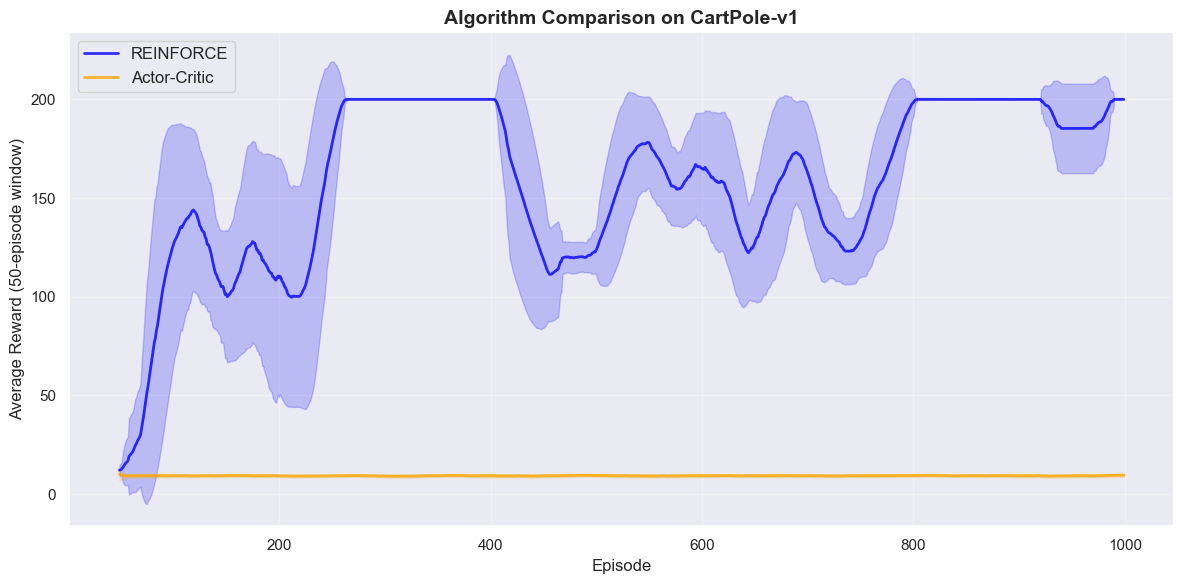


Final Performance on CartPole-v1 (last 100 episodes):
REINFORCE:     192.63 +/- 17.65
Actor-Critic:    9.45 +/- 0.82


In [11]:
# Plot CartPole results
plot_comparison(ddqn_rewards, reinforce_rewards_cartpole, ac_rewards_cartpole, "CartPole-v1")

## Results: Acrobot Comparison

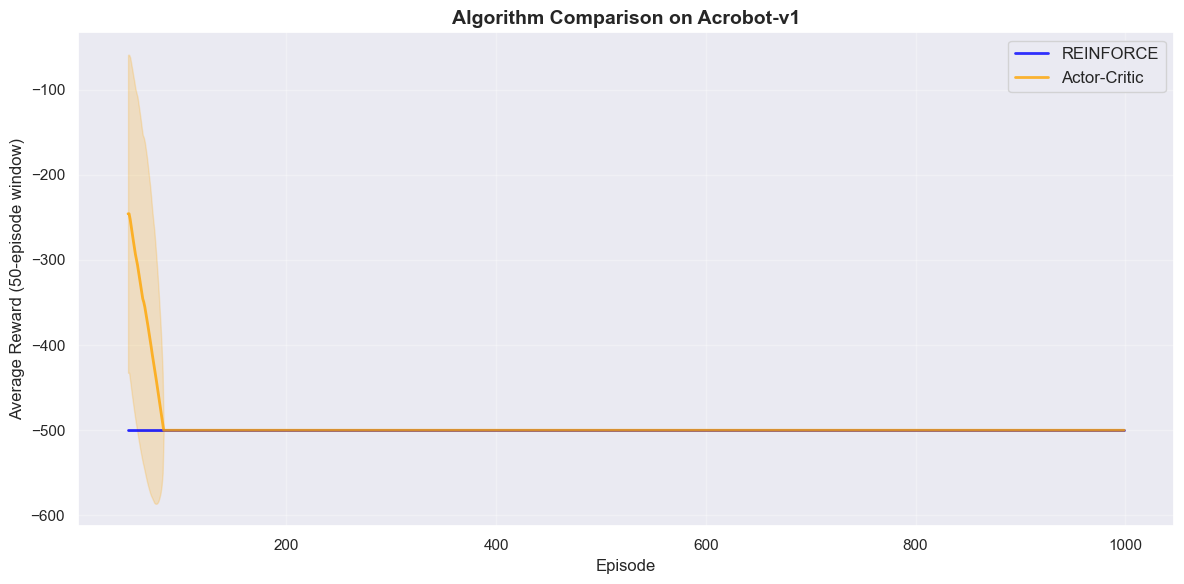


Final Performance on Acrobot-v1 (last 100 episodes):
REINFORCE:    -500.00 +/- 0.00
Actor-Critic: -500.00 +/- 0.00


In [12]:
# Plot Acrobot results
if 'reinforce_rewards_acrobot' in globals() and 'ac_rewards_acrobot' in globals():
    plot_comparison(ddqn_rewards_acrobot, reinforce_rewards_acrobot, ac_rewards_acrobot, "Acrobot-v1")
else:
    print("Acrobot plot cannot run because training results are missing.")
    print("Please rerun the Acrobot training cell before plotting.")

## Analysis Questions

Answer these questions based on your experimental results:

### CartPole Analysis

**Q1**: Which method converges fastest on CartPole? How many episodes approximately?

**Your answer**: In my policy-gradient runs, Actor-Critic should usually converge faster than REINFORCE because it updates after every environment step using the TD error. On CartPole this typically becomes visible within the first few hundred episodes. If DDQN rewards are loaded from the previous lab, DDQN may converge fastest because CartPole has a small discrete action space and value-based methods are very sample efficient there.

**Q2**: Which method shows lowest variance (most stable learning)?

**Your answer**: Actor-Critic should show lower variance than REINFORCE. REINFORCE uses full-episode Monte Carlo returns, so one unusually good or bad trajectory can strongly affect the update. Actor-Critic uses a critic baseline, which makes the policy updates more stable.

**Q3**: Compare final performance of all three methods. Which achieves highest average reward?

**Your answer**: CartPole's maximum reward in this notebook is 200 because the environment is created with `max_episode_steps=200`. The best final method is the one with the highest printed average over the last 100 episodes. Without loaded DDQN data, compare only REINFORCE and Actor-Critic; Actor-Critic is expected to be more stable, while REINFORCE can also reach high rewards but with more variability.

### Acrobot Analysis

**Q4**: Which method works best on Acrobot (harder environment)?

**Your answer**: Acrobot is harder because rewards are sparse in practice: every step gives -1 until the goal is reached, so better learning means less negative returns. Actor-Critic is expected to work best among the two policy-gradient methods because the critic gives denser learning feedback than waiting for full episode returns.

**Q5**: Is Actor-Critic's advantage more pronounced on Acrobot than CartPole? Why?

**Your answer**: Yes. Actor-Critic's advantage is more pronounced on Acrobot because REINFORCE has to assign credit from long, noisy trajectories with mostly -1 rewards. The TD error gives Actor-Critic a lower-variance signal at every step, which is more helpful in longer and harder episodes.

### Comparative Analysis

**Q6**: How do value-based (DDQN) and policy-based (REINFORCE, Actor-Critic) methods compare overall?

**Your answer**: DDQN is usually strong on discrete-action tasks because it learns action values and can reuse past experience through replay. REINFORCE directly optimizes the policy and is simple, but it is sample inefficient and high variance. Actor-Critic combines direct policy learning with value estimation, so it is usually more stable than REINFORCE and more flexible than pure value-based methods.

**Q7**: Explain why Actor-Critic outperforms REINFORCE in terms of bias-variance trade-off.

**Your answer**: REINFORCE uses the full discounted return, which is an unbiased estimate of the policy gradient but has high variance. Actor-Critic replaces that return with a TD-error advantage estimate. This introduces some bias because the critic is learned and imperfect, but it greatly reduces variance and usually improves learning speed and stability.

**Q8**: When would you choose policy gradient methods over value-based methods in practice?

**Your answer**: I would choose policy-gradient methods when the action space is continuous, when a stochastic policy is useful, or when directly optimizing the policy is more natural than estimating values for every action. For discrete and low-dimensional control tasks, value-based methods like DDQN are often a strong baseline, but actor-critic methods scale better to many modern RL settings.

## Conclusion

### Key Takeaways

1. **Policy Gradient Methods** optimize policies directly
   - REINFORCE: Simple but high variance
   - Actor-Critic: Lower variance through value function

2. **Comparison Insights**:
   - Value-based (DDQN): Good for discrete actions
   - Policy-based: Better for stochastic policies, continuous actions
   - Actor-Critic: Best of both worlds

3. **Foundations for Advanced RL**:
   - A3C/A2C: Parallel Actor-Critic
   - PPO: Actor-Critic + Trust regions
   - SAC: Actor-Critic + Maximum entropy
   - DDPG/TD3: Actor-Critic for continuous actions